In [ ]:
pip install hub

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

fatal: destination path 'free-spoken-digit-dataset' already exists and is not an empty directory.


#  **Time-Domain Analysis**

This code performs time-domain analysis on the Free-Spoken Digit Dataset (FSDD). It loads each audio file, removes silence, and normalizes the signal. Then it extracts several time-domain features such as zero-crossing rate, RMS energy, signal envelope, and autocorrelation.

These features describe how the signal behaves over time, including its energy, shape, and periodicity. After extracting the features, the code splits the data into training and testing sets, scales the features, and trains a Random Forest classifier to recognize the spoken digits.

Finally, the code evaluates the model accuracy and generates plots such as waveform with envelope, autocorrelation, confusion matrix, and feature comparisons to help understand the results.

In [ ]:
import numpy as np
import librosa
import pandas as pd
from pathlib import Path
from scipy.signal import hilbert
from scipy.stats import skew, kurtosis
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.signal import hilbert

# ==============================
# DATASET PATH
# ==============================
DATA_DIR = Path("/content/free-spoken-digit-dataset/recordings")
files = sorted(DATA_DIR.glob("*.wav"))

if len(files) == 0:
    raise FileNotFoundError("No .wav files found. Check DATA_DIR.")


# ==============================
# HELPER FUNCTIONS
# ==============================
def parse_filename(file_path):
    parts = file_path.stem.split("_")
    digit = int(parts[0])
    speaker = parts[1]
    index = int(parts[2])
    return digit, speaker, index


def load_audio(file_path):
    y, sr = librosa.load(file_path, sr=None, mono=True)

    # Remove silence
    y, _ = librosa.effects.trim(y, top_db=20)

    # Normalize amplitude
    max_abs = np.max(np.abs(y))
    if max_abs > 0:
        y = y / max_abs

    return y, sr


def safe_stats(x):
    x = np.asarray(x)

    if len(x) == 0:
        return [0, 0, 0, 0, 0, 0]

    std = np.std(x)

    if std == 0:
        return [
            np.min(x),
            np.max(x),
            np.mean(x),
            std,
            0,
            0
        ]

    return [
        np.min(x),
        np.max(x),
        np.mean(x),
        std,
        skew(x),
        kurtosis(x)
    ]


def autocorrelation_features(y, sr):
    y = y - np.mean(y)

    autocorr = np.correlate(y, y, mode="full")
    autocorr = autocorr[len(autocorr)//2:]

    if autocorr[0] != 0:
        autocorr = autocorr / autocorr[0]

    # pitch-related region: 5 ms to 30 ms
    start = int(0.005 * sr)
    end = int(0.030 * sr)

    region = autocorr[start:end]

    if len(region) == 0:
        return [0, 0, 0, 0]

    peak = np.max(region)
    mean = np.mean(region)
    std = np.std(region)
    peak_lag_ms = (np.argmax(region) + start) * 1000 / sr

    return [peak, mean, std, peak_lag_ms]


# ==============================
# FEATURE EXTRACTION
# ==============================
def extract_features(file_path):
    y, sr = load_audio(file_path)

    if len(y) < 10:
        return None

    # Zero-crossing rate
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    zcr_features = safe_stats(zcr)

    # RMS energy
    rms = librosa.feature.rms(y=y)[0]
    rms_features = safe_stats(rms)

    # Envelope
    envelope = np.abs(hilbert(y))
    envelope_features = safe_stats(envelope)

    # Global time-domain features
    duration = len(y) / sr
    energy = np.sum(y ** 2)
    abs_mean = np.mean(np.abs(y))
    variance = np.var(y)
    peak = np.max(np.abs(y))

    signal_rms = np.sqrt(np.mean(y ** 2)) + 1e-8
    crest_factor = peak / signal_rms

    # Silence ratio after trimming
    silence_ratio = np.mean(np.abs(y) < 0.02)

    # Autocorrelation features
    ac_features = autocorrelation_features(y, sr)

    features = (
        zcr_features +
        rms_features +
        envelope_features +
        [
            duration,
            energy,
            abs_mean,
            variance,
            peak,
            crest_factor,
            silence_ratio
        ] +
        ac_features
    )

    return np.array(features, dtype=float)


# ==============================
# BUILD DATASET
# ==============================
X = []
y = []
filenames = []

for f in files:
    digit, speaker, index = parse_filename(f)
    features = extract_features(f)

    if features is None:
        continue

    X.append(features)
    y.append(digit)
    filenames.append(f.name)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ==============================
# TRAIN / TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    stratify=y,
    random_state=42
)


# ==============================
# SCALE FEATURES
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==============================
# RANDOM FOREST MODEL
# ==============================
model = RandomForestClassifier(
    n_estimators=600,
    max_depth=25,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42
)

model.fit(X_train, y_train)


# ==============================
# EVALUATION
# ==============================
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("\n==============================")
print("IMPROVED TIME-DOMAIN RESULTS")
print("==============================")
print(f"Accuracy: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

X shape: (3000, 29)
y shape: (3000,)

IMPROVED TIME-DOMAIN RESULTS
Accuracy: 74.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81        30
           1       0.77      0.67      0.71        30
           2       0.65      0.73      0.69        30
           3       0.48      0.53      0.51        30
           4       0.68      0.77      0.72        30
           5       0.78      0.60      0.68        30
           6       0.87      0.90      0.89        30
           7       0.81      0.83      0.82        30
           8       0.85      0.77      0.81        30
           9       0.79      0.77      0.78        30

    accuracy                           0.74       300
   macro avg       0.75      0.74      0.74       300
weighted avg       0.75      0.74      0.74       300


Confusion Matrix:
[[25  0  1  2  1  0  0  0  0  1]
 [ 2 20  0  2  1  0  0  2  1  2]
 [ 1  0 22  6  1  0  0  0  0  0]
 [ 1  0  7 16  

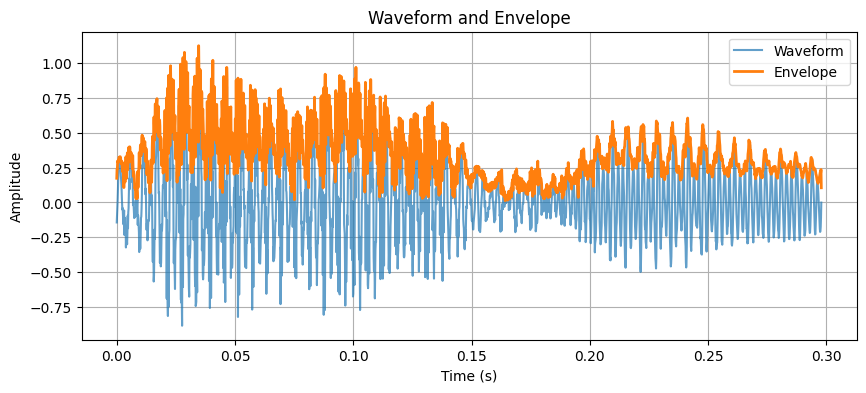

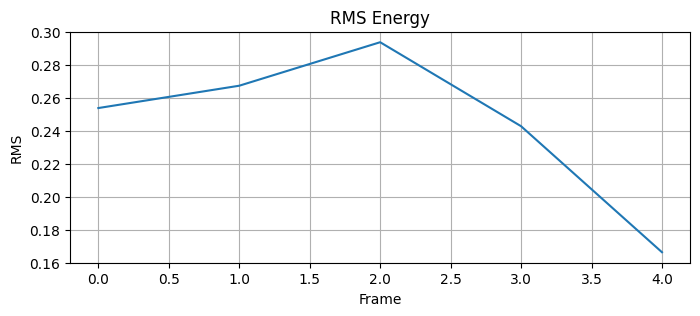

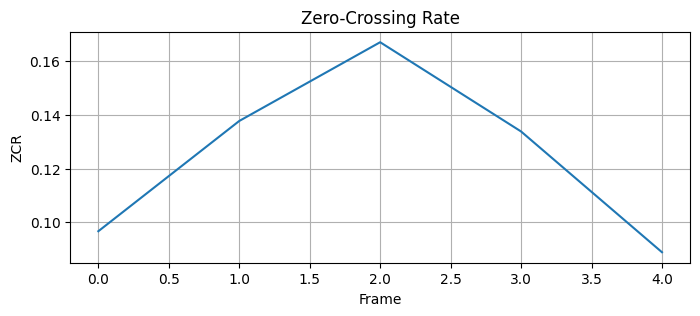

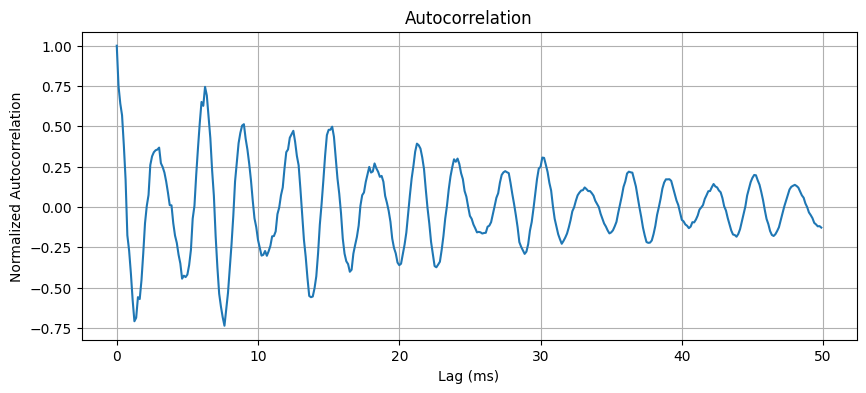

In [ ]:
example_file = files[0]
y_ex, sr_ex = load_audio(example_file)

time = np.arange(len(y_ex)) / sr_ex

# Compute features for plotting
zcr_ex = librosa.feature.zero_crossing_rate(y=y_ex)[0]
rms_ex = librosa.feature.rms(y=y_ex)[0]
envelope_ex = np.abs(hilbert(y_ex))
autocorr_ex = autocorrelation_full(y_ex)


# 1. Waveform + Envelope (for slide)
plt.figure(figsize=(10, 4))
plt.plot(time, y_ex, label="Waveform", alpha=0.7)
plt.plot(time, envelope_ex, label="Envelope", linewidth=2)
plt.title("Waveform and Envelope")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()


# 2. RMS Energy
plt.figure(figsize=(8, 3))
plt.plot(rms_ex)
plt.title("RMS Energy")
plt.xlabel("Frame")
plt.ylabel("RMS")
plt.grid(True)
plt.show()


# 3. Zero-Crossing Rate
plt.figure(figsize=(8, 3))
plt.plot(zcr_ex)
plt.title("Zero-Crossing Rate")
plt.xlabel("Frame")
plt.ylabel("ZCR")
plt.grid(True)
plt.show()


# 4. Autocorrelation
max_lag_ms = 50
max_lag_samples = int((max_lag_ms / 1000) * sr_ex)
lags_ms = np.arange(max_lag_samples) * 1000 / sr_ex

plt.figure(figsize=(10, 4))
plt.plot(lags_ms, autocorr_ex[:max_lag_samples])
plt.title("Autocorrelation")
plt.xlabel("Lag (ms)")
plt.ylabel("Normalized Autocorrelation")
plt.grid(True)
plt.show()